In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from WBUtiles.WBClean import clean_wb_wide
from WBUtiles.WBSummary import summary_wb, plot_missing_heatmap
from WBUtiles.WBLatex import make_lookup_latex, make_summary_latex

sns.set_theme(
    style="whitegrid",     # clean academic look
    context="paper",       # scales text for papers
    font_scale=1.1
)

# Data Cleaning

In [2]:
# import data
demo = pd.read_csv('../../data/Zambia_Demographic/demo.csv')
pop = pd.read_csv('../../data/Zambia_Population/pop.csv')

In [3]:
demo_clean, demo_lookup = clean_wb_wide(demo, drop_top_rows=0)
pop_clean, pop_lookup = clean_wb_wide(pop, drop_top_rows=0)

In [4]:
demo_lookup

,Series Code,Series Name
0,SP.POP.TOTL,"Population, total"
1,SP.POP.TOTL.MA.ZS,"Population, male (% of total population)"
2,SP.POP.TOTL.FE.ZS,"Population, female (% of total population)"
3,SP.POP.GROW,Population growth (annual %)
4,EN.POP.DNST,Population density (people per sq. km of land ...
5,SP.POP.0014.TO.ZS,Population ages 0-14 (% of total population)
6,SP.POP.1564.TO.ZS,Population ages 15-64 (% of total population)
7,SP.POP.65UP.TO.ZS,Population ages 65 and above (% of total popul...
8,SP.DYN.CDRT.IN,"Death rate, crude (per 1,000 people)"
9,SP.DYN.CBRT.IN,"Birth rate, crude (per 1,000 people)"


In [5]:
pop_lookup

,Series Code,Series Name
0,SP.POP.TOTL,"Population, total"
1,SP.POP.TOTL.MA.IN,"Population, male"
2,SP.POP.TOTL.FE.IN,"Population, female"
3,SP.POP.TOTL.MA.ZS,"Population, male (% of total population)"
4,SP.POP.TOTL.FE.ZS,"Population, female (% of total population)"
...,...,...
57,EN.URB.LCTY.UR.ZS,Population in the largest city (% of urban pop...
58,EN.URB.MCTY,Population in urban agglomerations of more tha...
59,EN.URB.MCTY.TL.ZS,Population in urban agglomerations of more tha...
60,EN.POP.EL5M.ZS,Population living in areas where elevation is ...


In [6]:
print(
    make_lookup_latex(demo_lookup,
                      caption='World Bank indicators used in Demographic Analysis',
                      label='tab:demo_indicator_list')
)

\begin{table}
\caption{World Bank indicators used in Demographic Analysis}
\label{tab:demo_indicator_list}
\begin{tabular}{lp{10cm}}
\toprule
Series Code & Series Name \\
\midrule
SP.POP.TOTL & Population, total \\
SP.POP.TOTL.MA.ZS & Population, male (\% of total population) \\
SP.POP.TOTL.FE.ZS & Population, female (\% of total population) \\
SP.POP.GROW & Population growth (annual \%) \\
EN.POP.DNST & Population density (people per sq. km of land area) \\
SP.POP.0014.TO.ZS & Population ages 0-14 (\% of total population) \\
SP.POP.1564.TO.ZS & Population ages 15-64 (\% of total population) \\
SP.POP.65UP.TO.ZS & Population ages 65 and above (\% of total population) \\
SP.DYN.CDRT.IN & Death rate, crude (per 1,000 people) \\
SP.DYN.CBRT.IN & Birth rate, crude (per 1,000 people) \\
SP.DYN.TFRT.IN & Fertility rate, total (births per woman) \\
SP.POP.DPND & Age dependency ratio (\% of working-age population) \\
SP.POP.DPND.OL & Age dependency ratio, old (\% of working-age population) \\


# Check data availability by series and year

In [7]:
demo_summary = summary_wb(demo_clean, demo_lookup)
demo_summary

,Series Code,Series Name,missing_pct,n_obs,first_year,last_year
0,SP.POP.TOTL,"Population, total",0.000000,65,1960,2024
1,SP.POP.TOTL.MA.ZS,"Population, male (% of total population)",0.000000,65,1960,2024
2,SP.POP.TOTL.FE.ZS,"Population, female (% of total population)",0.000000,65,1960,2024
3,SP.POP.GROW,Population growth (annual %),1.538462,64,1961,2024
4,EN.POP.DNST,Population density (people per sq. km of land ...,3.076923,63,1961,2023
5,SP.POP.0014.TO.ZS,Population ages 0-14 (% of total population),0.000000,65,1960,2024
6,SP.POP.1564.TO.ZS,Population ages 15-64 (% of total population),0.000000,65,1960,2024
7,SP.POP.65UP.TO.ZS,Population ages 65 and above (% of total popul...,0.000000,65,1960,2024
8,SP.DYN.CDRT.IN,"Death rate, crude (per 1,000 people)",1.538462,64,1960,2023
9,SP.DYN.CBRT.IN,"Birth rate, crude (per 1,000 people)",1.538462,64,1960,2023


In [8]:
print(
    make_summary_latex(demo_summary,
                       caption='Data availability of Demographic (Zambia)',
                       label='tab:demo_data_availability')
)

\begin{table}
\caption{Data availability of Demographic (Zambia)}
\label{tab:demo_data_availability}
\begin{tabular}{lrrrr}
\toprule
Series Code & Missing (\textbackslash \%) & Obs. & First year & Last year \\
\midrule
SP.POP.TOTL & 0.00 & 65 & 1960 & 2024 \\
SP.POP.TOTL.MA.ZS & 0.00 & 65 & 1960 & 2024 \\
SP.POP.TOTL.FE.ZS & 0.00 & 65 & 1960 & 2024 \\
SP.POP.GROW & 1.50 & 64 & 1961 & 2024 \\
EN.POP.DNST & 3.10 & 63 & 1961 & 2023 \\
SP.POP.0014.TO.ZS & 0.00 & 65 & 1960 & 2024 \\
SP.POP.1564.TO.ZS & 0.00 & 65 & 1960 & 2024 \\
SP.POP.65UP.TO.ZS & 0.00 & 65 & 1960 & 2024 \\
SP.DYN.CDRT.IN & 1.50 & 64 & 1960 & 2023 \\
SP.DYN.CBRT.IN & 1.50 & 64 & 1960 & 2023 \\
SP.DYN.TFRT.IN & 1.50 & 64 & 1960 & 2023 \\
SP.POP.DPND & 0.00 & 65 & 1960 & 2024 \\
SP.POP.DPND.OL & 0.00 & 65 & 1960 & 2024 \\
SP.POP.DPND.YG & 0.00 & 65 & 1960 & 2024 \\
\bottomrule
\end{tabular}
\end{table}



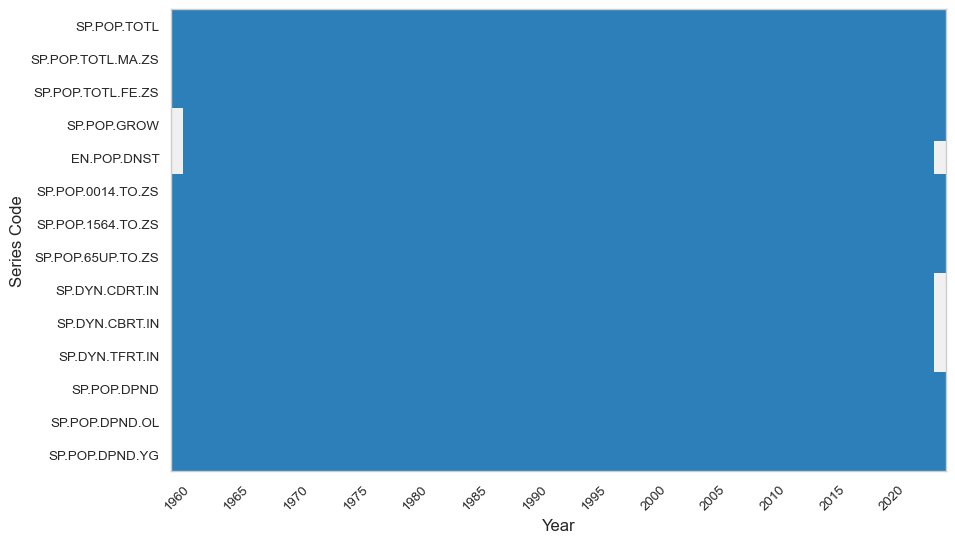

In [9]:
availability, fig, ax = plot_missing_heatmap(
    demo_clean,
    lookup=demo_lookup
)

fig.savefig(
    "../figures/Zambia/demographic/data_availability_heatmap.pdf",
    format="pdf",
    bbox_inches="tight"
)

# Population

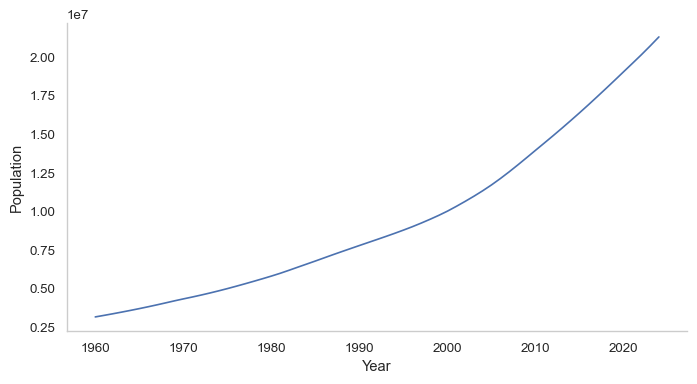

In [10]:
# Total population
df = demo_clean.set_index('Year')
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(df.index, df['SP.POP.TOTL'])

# ax.set_title('Total population')
ax.set_ylabel('Population')
ax.set_xlabel('Year')

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/Zambia/demographic/pop_total.pdf",
    format="pdf",
    bbox_inches="tight"
)

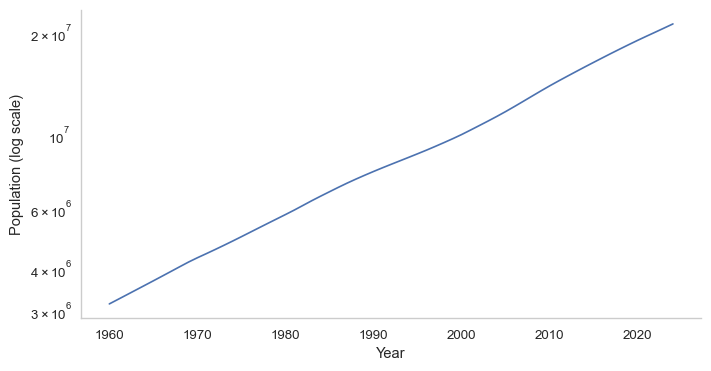

In [11]:
# Total population log
df = demo_clean.set_index('Year')
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(df.index, df['SP.POP.TOTL'])
ax.set_yscale('log')

# ax.set_title('Total population (log scale)')
ax.set_ylabel('Population (log scale)')
ax.set_xlabel('Year')

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/Zambia/demographic/pop_total_log.pdf",
    format="pdf",
    bbox_inches="tight"
)

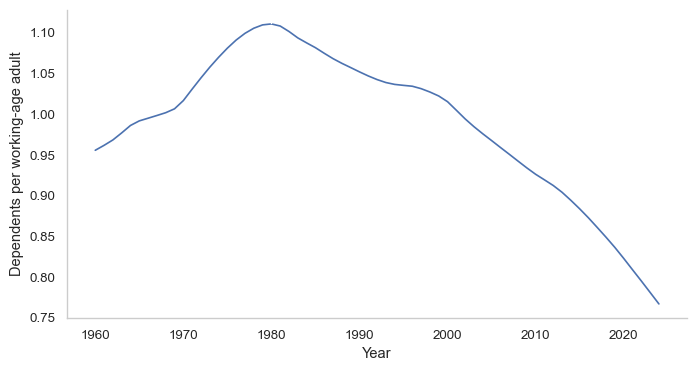

In [15]:
df = pop_clean.set_index('Year')
df['dependency_ratio'] = (
    (df['SP.POP.0014.TO.ZS'] + df['SP.POP.65UP.TO.ZS'])
    / df['SP.POP.1564.TO.ZS']
)
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(df.index, df['dependency_ratio'])
# ax.set_title('Demographic dependency ratio')
ax.set_xlabel('Year')
ax.set_ylabel('Dependents per working-age adult')

peak_year = df['dependency_ratio'].idxmax()
ax.axvline(peak_year, linestyle='--', linewidth=1)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/Zambia/demographic/dependecy_ratio.pdf",
    format="pdf",
    bbox_inches="tight"
)

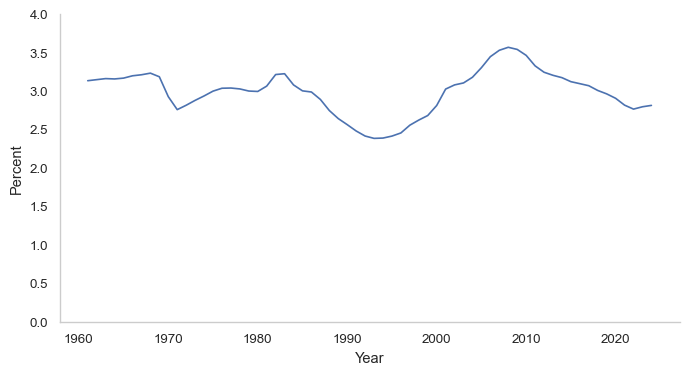

In [16]:
df = pop_clean.set_index('Year')
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(df.index, df['SP.POP.GROW'])
ax.axhline(0, linewidth=1)

# ax.set_title('Population growth rate')
ax.set_ylabel('Percent')
ax.set_xlabel('Year')
ax.set_ylim(0, 4)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/Zambia/demographic/pop_growth.pdf",
    format="pdf",
    bbox_inches="tight"
)

In [17]:
# keep annual growth
df_growth = pop_clean[['Year', 'SP.POP.GROW']].dropna()

# define decade
df_growth['decade'] = (df_growth['Year'] // 10) * 10

# compute average annual growth per decade
decadal_avg = (
    df_growth.groupby('decade')['SP.POP.GROW']
    .mean()
    .reset_index()
)

# keep only full decades if you prefer (optional)
# decadal_avg = decadal_avg[decadal_avg['decade'] >= 1980]

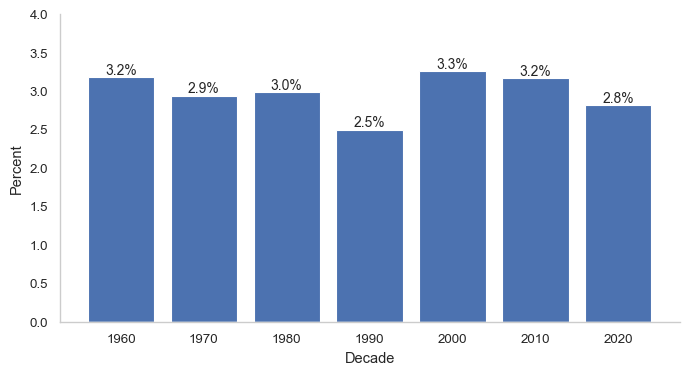

In [18]:
fig, ax = plt.subplots(figsize=(8,4))

bars = ax.bar(
    decadal_avg['decade'].astype(str),
    decadal_avg['SP.POP.GROW']
)

ax.axhline(0, linewidth=1)
# ax.set_title('Average annual population growth by decade')
ax.set_xlabel('Decade')
ax.set_ylabel('Percent')

ax.set_ylim(0, 4)

# Add percentage labels above bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

# Clean style (journal ready)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/Zambia/demographic/pop_growth_decade.pdf",
    format="pdf",
    bbox_inches="tight"
)

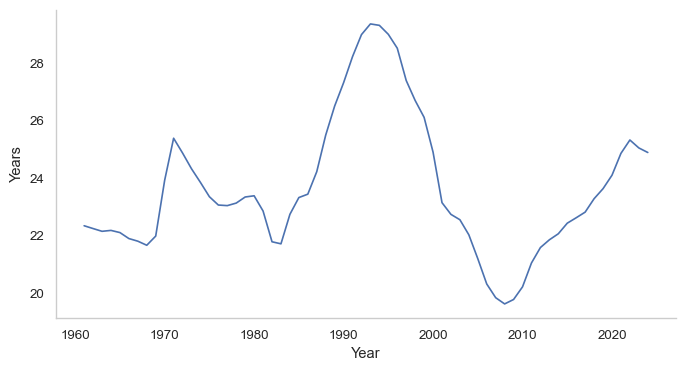

In [19]:
df = demo_clean[['Year', 'SP.POP.GROW']].dropna()
df = df.set_index('Year')

# Avoid division by zero or negative growth
df['doubling_time'] = 70 / df['SP.POP.GROW']

fig, ax = plt.subplots(figsize=(8,4))

ax.plot(df.index, df['doubling_time'])

# ax.set_title('Population doubling time')
ax.set_ylabel('Years')
ax.set_xlabel('Year')

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/Zambia/demographic/pop_double_time.pdf",
    format="pdf",
    bbox_inches="tight"
)

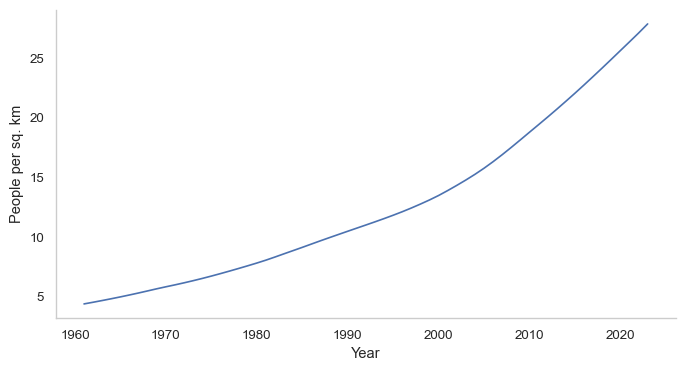

In [20]:
df = demo_clean.set_index('Year')

fig, ax = plt.subplots(figsize=(8,4))

ax.plot(df.index, df['EN.POP.DNST'])
# ax.set_title('Population density')
ax.set_ylabel('People per sq. km')
ax.set_xlabel('Year')

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/Zambia/demographic/pop_density.pdf",
    format="pdf",
    bbox_inches="tight"
)

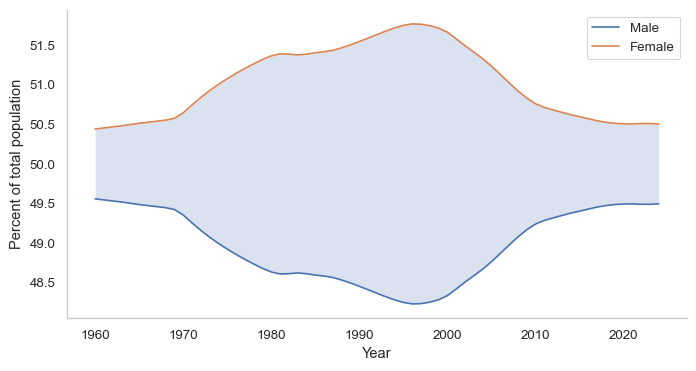

In [21]:
fig, ax = plt.subplots(figsize=(8,4))

df = pop_clean.set_index('Year')

ax.plot(df.index, 100 - df['SP.POP.TOTL.FE.ZS'], label='Male')
ax.plot(df.index, df['SP.POP.TOTL.FE.ZS'], label='Female')

# ax.set_title('Sex composition of the population')
ax.set_xlabel('Year')
ax.set_ylabel('Percent of total population')
ax.legend()

# fill between lines
ax.fill_between(df.index, 100 - df['SP.POP.TOTL.FE.ZS'], df['SP.POP.TOTL.FE.ZS'], alpha=0.2)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/Zambia/demographic/pop_sex.pdf",
    format="pdf",
    bbox_inches="tight"
)

In [22]:
df = pop_clean.set_index('Year')

age_groups = [
    'SP.POP.0509',
    'SP.POP.1014',
    'SP.POP.1519',
    'SP.POP.2024',
    'SP.POP.2529',
    'SP.POP.3034',
    'SP.POP.3539',
    'SP.POP.4044',
    'SP.POP.4549',
    'SP.POP.5054',
    'SP.POP.5559',
    'SP.POP.6064',
    'SP.POP.6569',
    'SP.POP.7074',
    'SP.POP.7579',
    'SP.POP.80UP'
]

labels = [
    '05–09','10–14','15–19','20–24','25–29','30–34',
    '35–39','40–44','45–49','50–54','55–59','60–64',
    '65–69','70–74','75–79','80+'
]

def plot_pyramid(year, ax):
    male = []
    female = []

    for g in age_groups:
        male.append(df.loc[year, g + '.MA.5Y'])
        female.append(df.loc[year, g + '.FE.5Y'])

    male = np.array(male)
    female = np.array(female)

    y = np.arange(len(labels))

    ax.barh(y, -male, align='center', label='Male')
    ax.barh(y, female, align='center', label='Female')

    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_title(str(year))
    ax.set_xlim(-max(male.max(), female.max())*1.2,
                 max(male.max(), female.max())*1.2)

    ax.axvline(0, linewidth=1)

    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

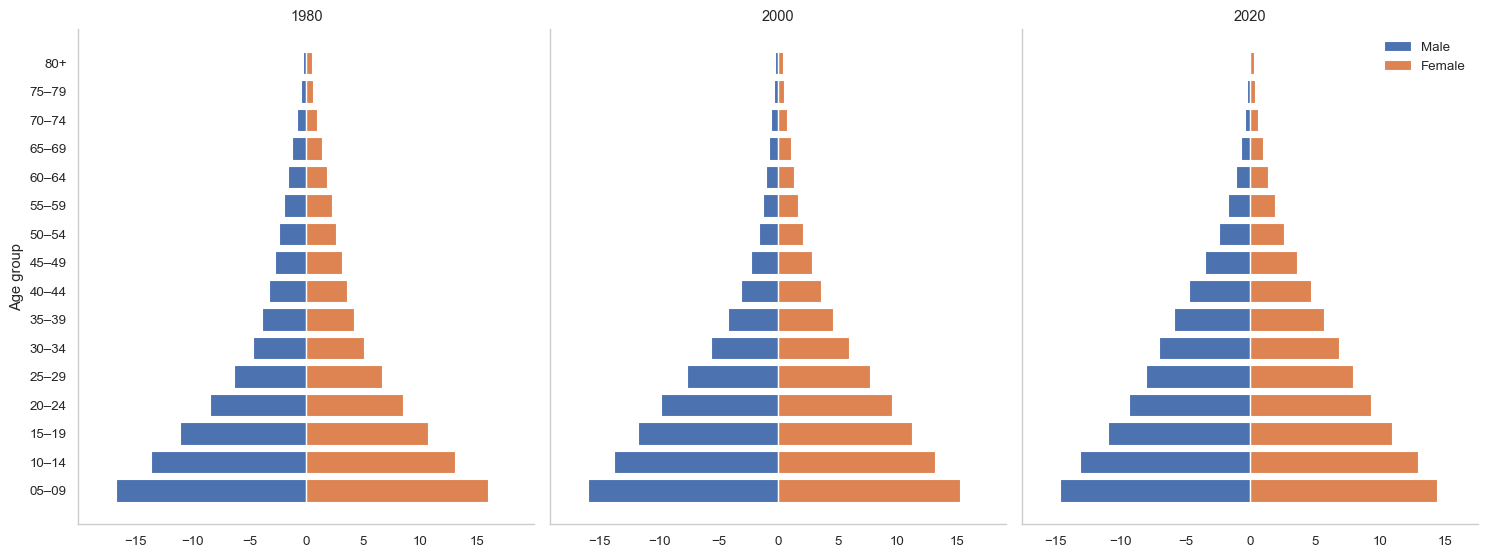

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

for ax, year in zip(axes, [1980, 2000, 2020]):
    plot_pyramid(year, ax)

axes[0].set_ylabel('Age group')

# fig.suptitle('Zambia: Population Pyramids (1980, 2000, 2020)', fontsize=13)
axes[2].legend(loc= 'upper right',frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(
    "../figures/Zambia/demographic/pop_pyramids.pdf",
    format="pdf",
    bbox_inches="tight"
)

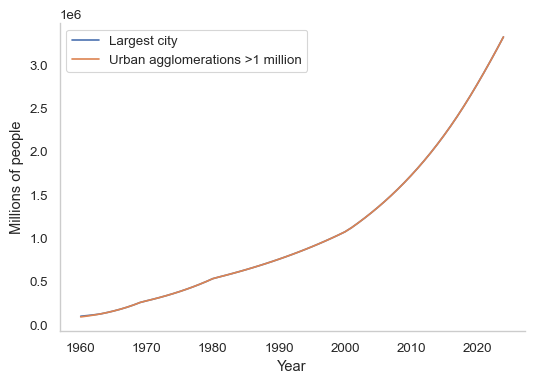

In [24]:
# Urban population
df = pop_clean.set_index('Year')

fig, ax = plt.subplots(figsize=(6,4))

ax.plot(df.index, df['EN.URB.LCTY'])
ax.plot(df.index, df['EN.URB.MCTY'])

# ax.set_title('Population in the largest city')
ax.set_xlabel('Year')
ax.set_ylabel('Millions of people')
ax.legend(['Largest city', 'Urban agglomerations >1 million'])

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/Zambia/demographic/pop_largest_city.pdf",
    format="pdf",
    bbox_inches="tight"
)

In [25]:
df = pop_clean.set_index('Year')
tmp = df[['EN.URB.LCTY', 'EN.URB.MCTY']].dropna()

(tmp['EN.URB.MCTY'] - tmp['EN.URB.LCTY']).describe()

count      65.000000
mean     -252.984615
std      1249.330815
min     -8026.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.000000
dtype: float64

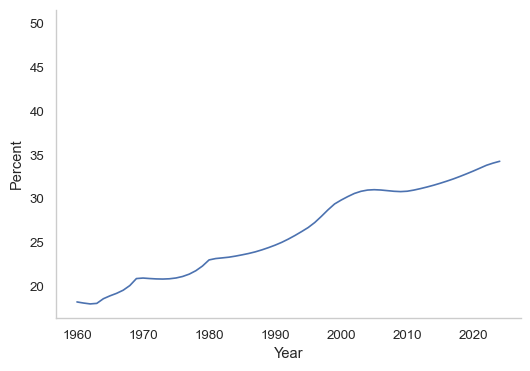

In [26]:
df = pop_clean.set_index('Year')
fig, ax = plt.subplots(figsize=(6,4))

ax.plot(df.index, df['EN.URB.LCTY.UR.ZS'])
ax.axhline(50, linestyle='--', linewidth=1)

# ax.set_title('Largest city share of urban population')
ax.set_xlabel('Year')
ax.set_ylabel('Percent')

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/Zambia/demographic/pop_percentage_largest_city.pdf",
    format="pdf",
    bbox_inches="tight"
)

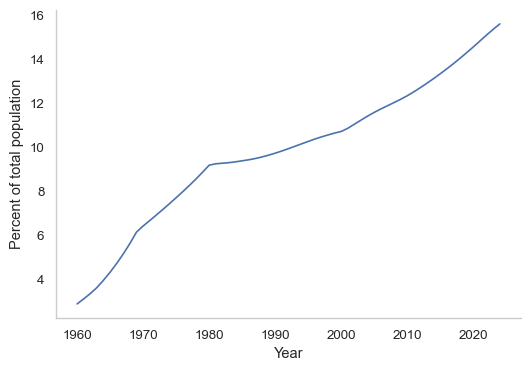

In [27]:
df = pop_clean.set_index('Year')
fig, ax = plt.subplots(figsize=(6,4))

ax.plot(df.index, df['EN.URB.MCTY.TL.ZS'])

# ax.set_title('Share of population in cities >1 million')
ax.set_xlabel('Year')
ax.set_ylabel('Percent of total population')

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/Zambia/demographic/pop_city.pdf",
    format="pdf",
    bbox_inches="tight"
)

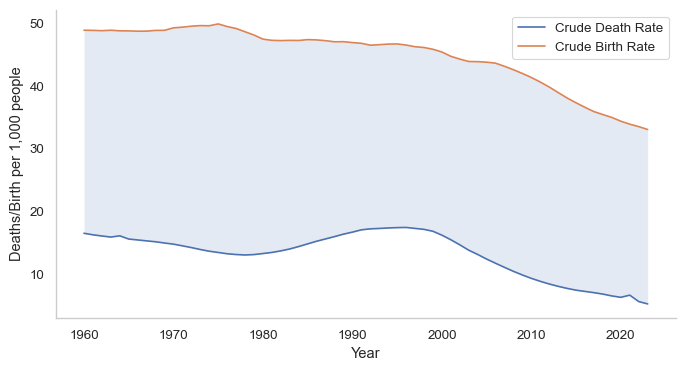

In [28]:
# Crude Death/Birth Rate
df = demo_clean.set_index('Year')

fig, ax = plt.subplots(figsize=(8,4))

ax.plot(df.index, df['SP.DYN.CDRT.IN'])
ax.plot(df.index, df['SP.DYN.CBRT.IN'])
# ax.set_title('Crude Death/Birth Rate')
ax.set_ylabel('Deaths/Birth per 1,000 people')
ax.set_xlabel('Year')
ax.legend(['Crude Death Rate', 'Crude Birth Rate'])

ax.fill_between(
    df.index,
    df['SP.DYN.CDRT.IN'],   # lower line
    df['SP.DYN.CBRT.IN'],   # upper line
    alpha=0.15
)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


fig.savefig(
    "../figures/Zambia/demographic/crude_death_birth.pdf",
    format="pdf",
    bbox_inches="tight"
)

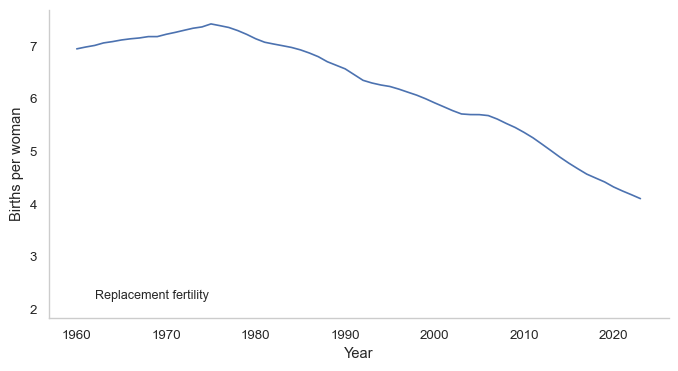

In [29]:
df = demo_clean.set_index('Year')
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(df.index, df['SP.DYN.TFRT.IN'])

# ax.set_title('Total fertility rate')
ax.set_xlabel('Year')
ax.set_ylabel('Births per woman')

ax.axhline(2.1, linestyle='--', linewidth=1)
ax.text(1962, 2.2, 'Replacement fertility', fontsize=9)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/Zambia/demographic/total_fertility.pdf",
    format="pdf",
    bbox_inches="tight"
)